# Step 7: Experiment With Various Models

## Objective

The objective of this notebook is to build a reproducible process for comparing, validating, and tuning multiple machine learning models for bank customer churn prediction.

The primary performance metric will be the **F1 score for the churn class** because the target variable is imbalanced and the business problem requires balancing precision and recall. ROC-AUC will be used as a secondary metric to evaluate each model's ability to distinguish between customers who remain with the bank and customers who exit.

This notebook will:

- Compare multiple machine learning model types.
- Use stratified cross-validation.
- Automate model training and evaluation.
- Tune the strongest candidate models.
- Compare training and validation performance.
- Evaluate potential overfitting and underfitting.
- Measure training time and serialized model size.
- Select and save the best-performing model.

In [1]:
# Standard libraries
import time
import pickle
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Notebook settings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Load the Cleaned Dataset

This notebook uses the cleaned dataset produced during Step 5. The code checks several common file locations so the notebook can run from either the repository root or the `notebooks` folder.

In [2]:
candidate_paths = [
    Path("customer_churn_cleaned.csv"),
    Path("../data/customer_churn_cleaned.csv"),
    Path("data/customer_churn_cleaned.csv")
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find customer_churn_cleaned.csv. "
        "Place it in the same folder as the notebook or in the repository data folder."
    )

df = pd.read_csv(data_path)

print(f"Loaded: {data_path}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Loaded: ../data/customer_churn_cleaned.csv
Rows: 10,000
Columns: 9


,CreditScore,Age,Tenure,Balance,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,844,18,2,160980.03,145936.28,0,0,0,1
1,656,18,10,151762.74,127014.32,0,0,0,1
2,570,18,4,82767.42,71811.90,0,0,0,0
3,716,18,3,128743.80,197322.13,0,1,0,0
4,727,18,4,133550.67,46941.41,0,0,0,1


## Prepare Features and Target

The target variable is `Exited`, where:

- `0` indicates the customer stayed with the bank.
- `1` indicates the customer exited the bank.

The remaining columns are used as predictor variables. A stratified train/test split is used so the churn proportion remains consistent in both datasets.

In [3]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nOverall target distribution:")
print(y.value_counts(normalize=True).rename("Proportion"))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).rename("Proportion"))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).rename("Proportion"))

Training feature shape: (8000, 8)
Testing feature shape: (2000, 8)

Overall target distribution:
Exited
0    0.7963
1    0.2037
Name: Proportion, dtype: float64

Training target distribution:
Exited
0    0.79625
1    0.20375
Name: Proportion, dtype: float64

Testing target distribution:
Exited
0    0.7965
1    0.2035
Name: Proportion, dtype: float64


## Define Candidate Models

Several machine learning algorithms are evaluated to determine which model performs best for customer churn prediction.

The models selected represent a variety of learning approaches:

- Dummy Baseline
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- Gradient Boosting
- Histogram Gradient Boosting

Models that require standardized features are wrapped inside a preprocessing pipeline using `StandardScaler`. Tree-based models do not require feature scaling.

In [4]:
models = {

    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent",
        random_state=RANDOM_STATE
    ),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=15
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=4,
        class_weight="balanced",
        n_jobs=1,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "Histogram Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=15,
        random_state=RANDOM_STATE
    )

}

print(f"{len(models)} models prepared.")

7 models prepared.


## Automated Cross-Validation

A five-fold stratified cross-validation process is used to compare each machine learning model. This approach reduces dependence on a single train/test split and provides a more reliable estimate of model performance.

The following metrics are collected for each model:

- Accuracy
- Precision
- Recall
- F1 Score (primary metric)
- ROC-AUC
- Training F1 Score
- Generalization Gap
- Model Training Time
- Model Size

In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

experiment_rows = []
fitted_models = {}

for model_name, model in models.items():

    estimator = clone(model)

    start_time = time.perf_counter()

    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=1
    )

    total_time = time.perf_counter() - start_time

    estimator.fit(X_train, y_train)

    fitted_models[model_name] = estimator

    train_f1 = scores["train_f1"].mean()
    validation_f1 = scores["test_f1"].mean()

    experiment_rows.append({

        "Model": model_name,

        "CV Accuracy": scores["test_accuracy"].mean(),

        "CV Precision": scores["test_precision"].mean(),

        "CV Recall": scores["test_recall"].mean(),

        "CV F1": validation_f1,

        "CV ROC-AUC": scores["test_roc_auc"].mean(),

        "Train F1": train_f1,

        "Generalization Gap": train_f1 - validation_f1,

        "F1 Std Dev": scores["test_f1"].std(),

        "Training Time (sec)": scores["fit_time"].mean(),

        "Model Size (KB)": len(pickle.dumps(estimator)) / 1024

    })

results = pd.DataFrame(experiment_rows)

results = results.sort_values(
    by=["CV F1", "CV ROC-AUC"],
    ascending=False
).reset_index(drop=True)

results.round(4)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Train F1,Generalization Gap,F1 Std Dev,Training Time (sec),Model Size (KB)
0,Random Forest,0.7684,0.4494,0.5982,0.5129,0.7817,0.6668,0.1539,0.0273,0.7721,10044.5186
1,Logistic Regression,0.7182,0.3909,0.6865,0.4980,0.7554,0.4958,-0.0023,0.0220,0.0324,1.4922
2,Decision Tree,0.7130,0.3854,0.6853,0.4929,0.7563,0.5322,0.0393,0.0092,0.0106,9.5195
3,Histogram Gradient Boosting,0.8241,0.6424,0.3123,0.4198,0.7828,0.5455,0.1257,0.0131,0.2338,351.4160
4,Gradient Boosting,0.8219,0.6440,0.2853,0.3947,0.7847,0.4431,0.0484,0.0140,0.7798,197.0459
5,K-Nearest Neighbors,0.8101,0.5953,0.2141,0.3148,0.7302,0.3662,0.0513,0.0273,0.0028,706.7217
6,Dummy Baseline,0.7962,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,0.0000,0.0006,0.6572


## Compare Cross-Validation Performance

The following charts compare model performance, training behavior, and computational efficiency. These visualizations help identify which models perform well and whether any models may be overfitting.

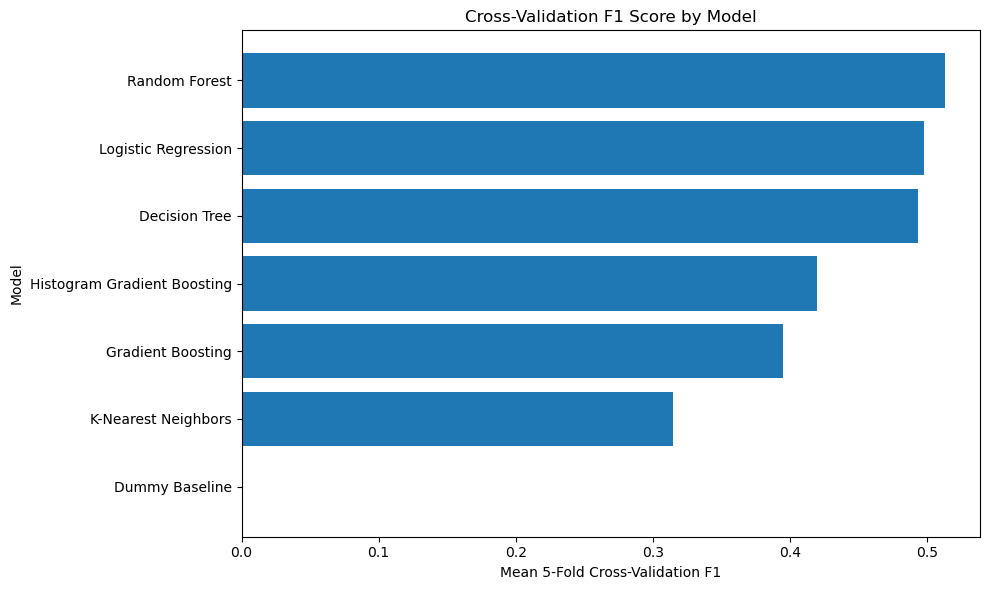

In [6]:
plot_df = results.sort_values("CV F1")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Model"], plot_df["CV F1"])
plt.xlabel("Mean 5-Fold Cross-Validation F1")
plt.ylabel("Model")
plt.title("Cross-Validation F1 Score by Model")
plt.tight_layout()
plt.show()

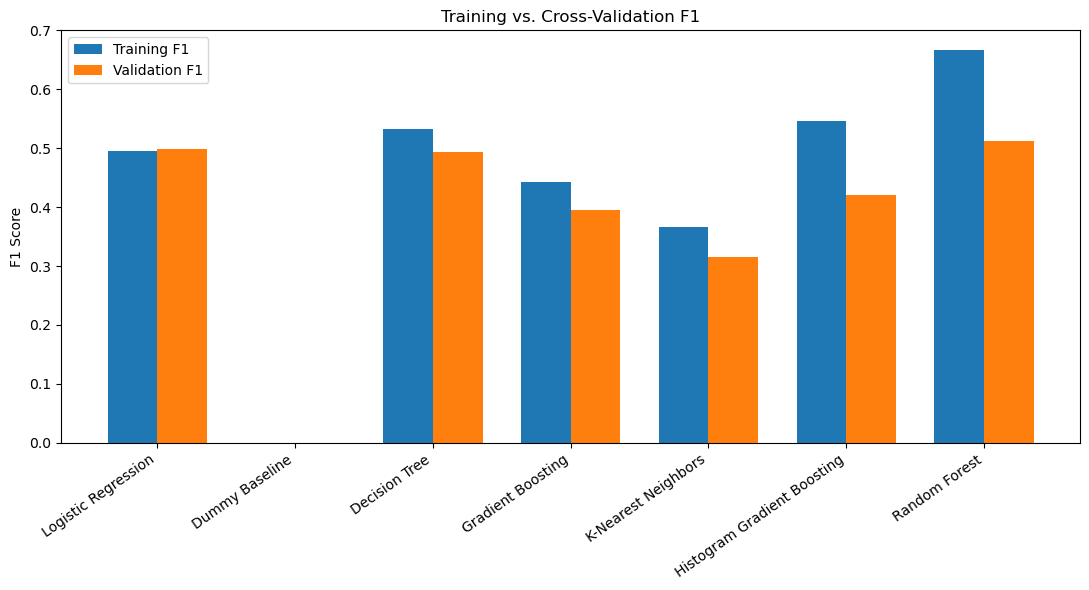

In [7]:
gap_df = results.sort_values("Generalization Gap")

x = np.arange(len(gap_df))
width = 0.36

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    gap_df["Train F1"],
    width,
    label="Training F1"
)

plt.bar(
    x + width / 2,
    gap_df["CV F1"],
    width,
    label="Validation F1"
)

plt.xticks(
    x,
    gap_df["Model"],
    rotation=35,
    ha="right"
)

plt.ylabel("F1 Score")
plt.title("Training vs. Cross-Validation F1")
plt.legend()
plt.tight_layout()
plt.show()

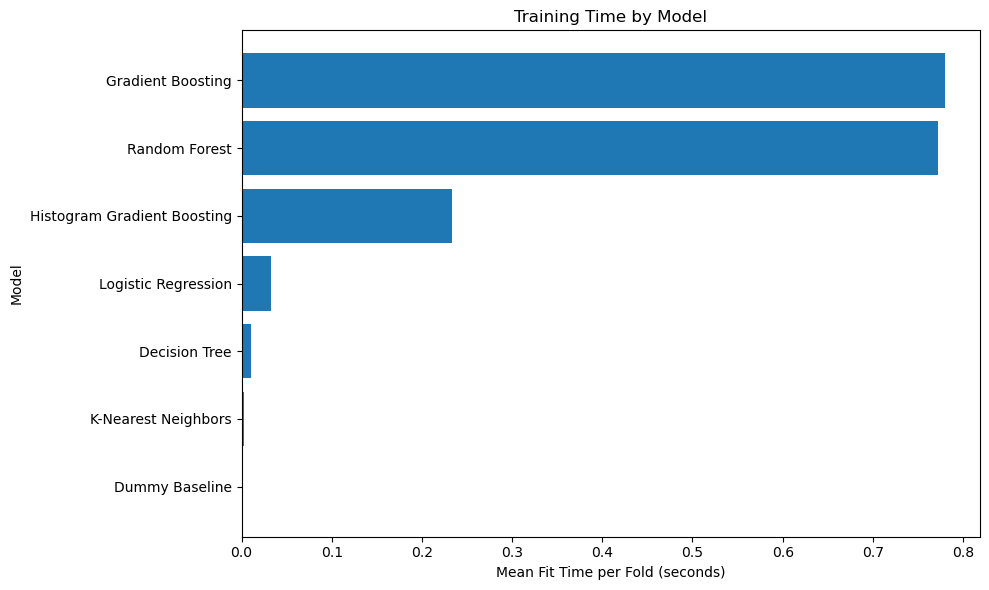

In [8]:
time_df = results.sort_values("Training Time (sec)")

plt.figure(figsize=(10, 6))
plt.barh(
    time_df["Model"],
    time_df["Training Time (sec)"]
)
plt.xlabel("Mean Fit Time per Fold (seconds)")
plt.ylabel("Model")
plt.title("Training Time by Model")
plt.tight_layout()
plt.show()

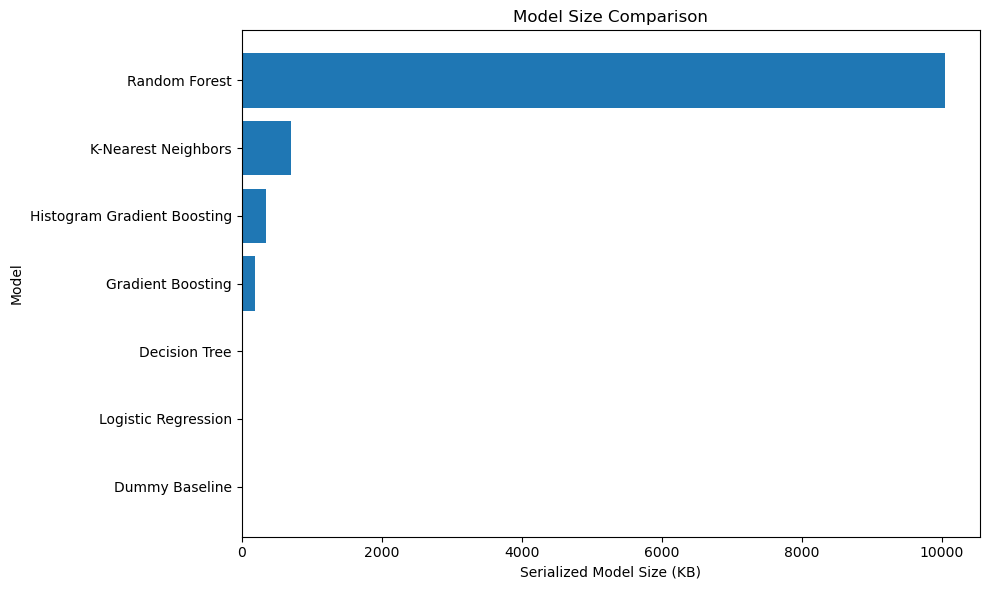

In [9]:
size_df = results.sort_values("Model Size (KB)")

plt.figure(figsize=(10, 6))
plt.barh(
    size_df["Model"],
    size_df["Model Size (KB)"]
)
plt.xlabel("Serialized Model Size (KB)")
plt.ylabel("Model")
plt.title("Model Size Comparison")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

The two strongest candidate models are Logistic Regression and Random Forest.

Logistic Regression demonstrated the highest recall and the smallest generalization gap, while Random Forest achieved the highest cross-validation F1 score. Both models are tuned using randomized search with stratified cross-validation.

F1 score is used as the optimization metric because the dataset is imbalanced and the project must balance precision and recall when identifying customers likely to churn.

In [10]:
# Hyperparameter search space for Logistic Regression
logistic_param_distributions = {
    "model__C": np.logspace(-3, 2, 20),
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],
    "model__class_weight": [None, "balanced"]
}

logistic_search = RandomizedSearchCV(
    estimator=clone(models["Logistic Regression"]),
    param_distributions=logistic_param_distributions,
    n_iter=12,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    return_train_score=True,
    verbose=1
)

logistic_start_time = time.perf_counter()

logistic_search.fit(X_train, y_train)

logistic_tuning_time = time.perf_counter() - logistic_start_time
tuned_logistic = logistic_search.best_estimator_

print("Logistic Regression tuning complete.")
print(f"Best CV F1: {logistic_search.best_score_:.4f}")
print(f"Tuning time: {logistic_tuning_time:.2f} seconds")

print("\nBest parameters:")
for parameter, value in logistic_search.best_params_.items():
    print(f"{parameter}: {value}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Logistic Regression tuning complete.
Best CV F1: 0.4980
Tuning time: 0.69 seconds

Best parameters:
model__solver: liblinear
model__penalty: l1
model__class_weight: balanced
model__C: 29.763514416313193


### Random Forest Hyperparameter Tuning

Random Forest produced the highest baseline cross-validation F1 score, but it also showed a larger gap between training and validation performance. Hyperparameter tuning is used to improve generalization while maintaining strong churn-detection performance.

In [11]:
# Hyperparameter search space for Random Forest
random_forest_param_distributions = {
    "n_estimators": [150, 200, 250, 300, 350],
    "max_depth": [5, 8, 10, 12, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [2, 4, 8, 12],
    "max_features": ["sqrt", "log2", 0.5],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

random_forest_search = RandomizedSearchCV(
    estimator=clone(models["Random Forest"]),
    param_distributions=random_forest_param_distributions,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    return_train_score=True,
    verbose=1
)

random_forest_start_time = time.perf_counter()

random_forest_search.fit(X_train, y_train)

random_forest_tuning_time = (
    time.perf_counter() - random_forest_start_time
)

tuned_random_forest = random_forest_search.best_estimator_

print("Random Forest tuning complete.")
print(f"Best CV F1: {random_forest_search.best_score_:.4f}")
print(f"Tuning time: {random_forest_tuning_time:.2f} seconds")

print("\nBest parameters:")
for parameter, value in random_forest_search.best_params_.items():
    print(f"{parameter}: {value}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Random Forest tuning complete.
Best CV F1: 0.5122
Tuning time: 85.57 seconds

Best parameters:
n_estimators: 350
min_samples_split: 2
min_samples_leaf: 2
max_features: log2
max_depth: 10
class_weight: balanced_subsample


## Baseline and Tuned Model Comparison

The baseline and tuned versions of Logistic Regression and Random Forest are compared using their cross-validation F1 scores, training F1 scores, and generalization gaps.

Hyperparameter tuning does not necessarily produce a better model. The final candidate is selected based on validation performance and generalization rather than assuming that the tuned model is superior.

In [12]:
def get_baseline_summary(model_name, display_name):
    row = results.loc[results["Model"] == model_name].iloc[0]

    return {
        "Candidate": display_name,
        "CV F1": row["CV F1"],
        "Train F1": row["Train F1"],
        "Generalization Gap": row["Generalization Gap"],
        "Selection Method": "Baseline"
    }


def get_tuned_summary(display_name, search):
    best_index = search.best_index_

    validation_f1 = search.cv_results_["mean_test_score"][best_index]
    training_f1 = search.cv_results_["mean_train_score"][best_index]

    return {
        "Candidate": display_name,
        "CV F1": validation_f1,
        "Train F1": training_f1,
        "Generalization Gap": training_f1 - validation_f1,
        "Selection Method": "RandomizedSearchCV"
    }


candidate_comparison = pd.DataFrame([
    get_baseline_summary(
        "Logistic Regression",
        "Baseline Logistic Regression"
    ),
    get_tuned_summary(
        "Tuned Logistic Regression",
        logistic_search
    ),
    get_baseline_summary(
        "Random Forest",
        "Baseline Random Forest"
    ),
    get_tuned_summary(
        "Tuned Random Forest",
        random_forest_search
    )
])

candidate_comparison = candidate_comparison.sort_values(
    by=["CV F1", "Generalization Gap"],
    ascending=[False, True]
).reset_index(drop=True)

candidate_comparison.round(4)

,Candidate,CV F1,Train F1,Generalization Gap,Selection Method
0,Baseline Random Forest,0.5129,0.6668,0.1539,Baseline
1,Tuned Random Forest,0.5122,0.7055,0.1933,RandomizedSearchCV
2,Baseline Logistic Regression,0.4980,0.4958,-0.0023,Baseline
3,Tuned Logistic Regression,0.4980,0.4958,-0.0022,RandomizedSearchCV


## Final Model Selection and Test Evaluation

The baseline Random Forest was selected as the final model because it achieved the highest mean cross-validation F1 score.

Although hyperparameter tuning was performed, the tuned Random Forest produced a slightly lower validation F1 score and a larger generalization gap. Therefore, the baseline model was retained.

The final model is now trained on the complete training dataset and evaluated once on the untouched test dataset.

In [13]:
# Select and train the final model
final_model_name = "Baseline Random Forest"
final_model = clone(models["Random Forest"])

final_training_start = time.perf_counter()
final_model.fit(X_train, y_train)
final_training_time = time.perf_counter() - final_training_start

# Generate predictions
train_predictions = final_model.predict(X_train)
test_predictions = final_model.predict(X_test)
test_probabilities = final_model.predict_proba(X_test)[:, 1]

# Calculate final metrics
final_test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Training F1",
        "Generalization Gap",
        "Training Time (sec)",
        "Model Size (KB)"
    ],
    "Value": [
        accuracy_score(y_test, test_predictions),
        precision_score(y_test, test_predictions),
        recall_score(y_test, test_predictions),
        f1_score(y_test, test_predictions),
        roc_auc_score(y_test, test_probabilities),
        f1_score(y_train, train_predictions),
        f1_score(y_train, train_predictions)
            - f1_score(y_test, test_predictions),
        final_training_time,
        len(pickle.dumps(final_model)) / 1024
    ]
})

print(f"Final model: {final_model_name}")
print("\nFinal held-out test results:")

display(final_test_metrics.round(4))

print("\nClassification report:")
print(classification_report(
    y_test,
    test_predictions,
    target_names=["Stayed", "Exited"]
))

Final model: Baseline Random Forest

Final held-out test results:


,Metric,Value
0,Accuracy,0.7660
1,Precision,0.4452
2,Recall,0.6093
3,F1 Score,0.5145
4,ROC-AUC,0.7838
5,Training F1,0.6436
6,Generalization Gap,0.1291
7,Training Time (sec),0.9552
8,Model Size (KB),10044.5186



Classification report:
              precision    recall  f1-score   support

      Stayed       0.89      0.81      0.85      1593
      Exited       0.45      0.61      0.51       407

    accuracy                           0.77      2000
   macro avg       0.67      0.71      0.68      2000
weighted avg       0.80      0.77      0.78      2000



## Confusion Matrix

The confusion matrix shows how the final model classified customers in the held-out test dataset. It distinguishes correctly identified customers from false positives and false negatives.

For churn prediction, false negatives are especially important because they represent customers who churned but were not identified as being at risk.

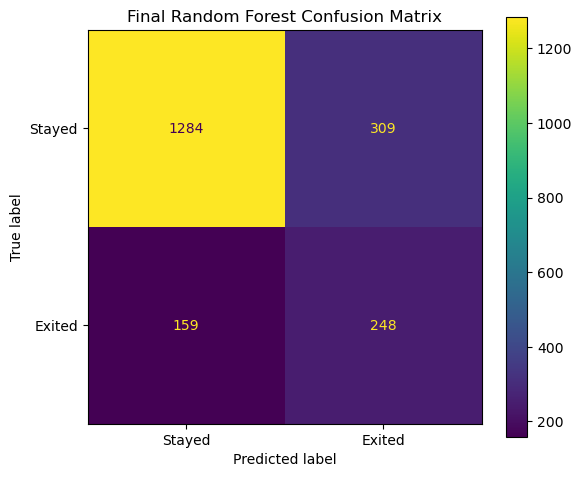

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["Stayed", "Exited"],
    values_format="d",
    ax=ax
)

ax.set_title("Final Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## ROC and Precision-Recall Curves

The ROC curve evaluates how well the model separates churners from non-churners across different classification thresholds.

The precision-recall curve focuses specifically on performance for the minority churn class and is especially useful for this imbalanced dataset.

<Figure size 700x600 with 0 Axes>

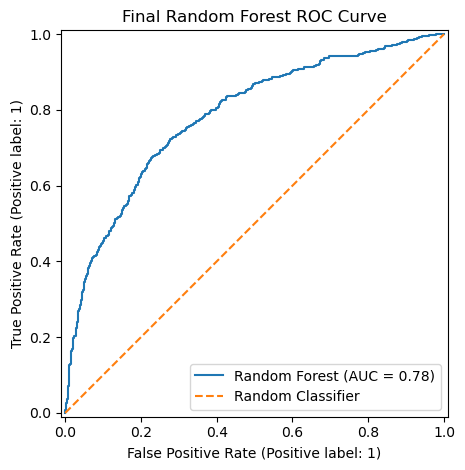

In [15]:
plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Final Random Forest ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 700x600 with 0 Axes>

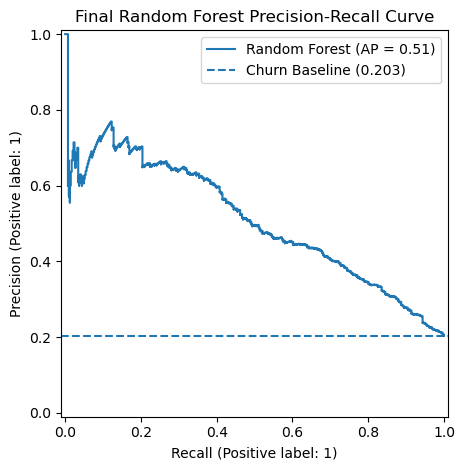

In [16]:
plt.figure(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="Random Forest"
)

baseline_rate = y_test.mean()

plt.axhline(
    baseline_rate,
    linestyle="--",
    label=f"Churn Baseline ({baseline_rate:.3f})"
)

plt.title("Final Random Forest Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance

Random Forest feature importance estimates how much each predictor contributed to the model's decisions. Higher values indicate that a feature played a larger role in separating customers who exited from those who stayed.

These values describe predictive influence and should not be interpreted as proof that a feature directly causes customer churn.

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,Age,0.467387
1,Balance,0.137315
2,EstimatedSalary,0.117037
3,CreditScore,0.112226
4,Geography_Germany,0.057154
5,Tenure,0.056664
6,Gender_Male,0.039548
7,Geography_Spain,0.012667


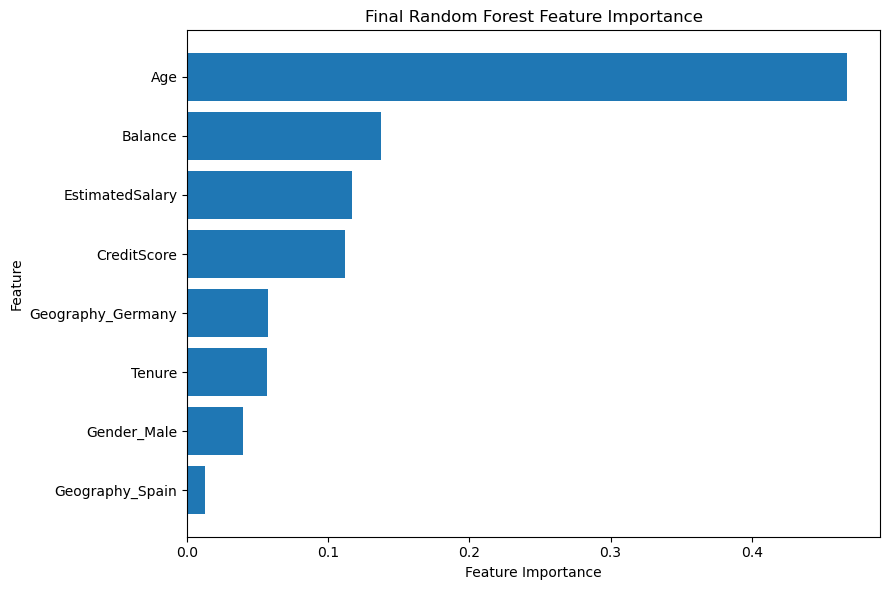

In [18]:
importance_plot = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    importance_plot["Feature"],
    importance_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Final Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## Save Final Model and Results

The final trained model, performance metrics, model-comparison results, and feature-importance values are saved as reusable project artifacts.

The model is compressed to reduce storage requirements. These files support reproducibility and future deployment.

In [19]:
import json
import joblib

# Locate the project root whether the notebook runs from
# the repository root or the notebooks folder.
if Path.cwd().name.lower() == "notebooks":
    project_root = Path.cwd().parent
else:
    project_root = Path.cwd()

artifact_dir = project_root / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

# Artifact paths
model_path = artifact_dir / "final_random_forest.joblib"
cv_results_path = artifact_dir / "cross_validation_results.csv"
candidate_results_path = artifact_dir / "candidate_comparison.csv"
test_metrics_path = artifact_dir / "final_test_metrics.csv"
feature_importance_path = artifact_dir / "feature_importance.csv"
metadata_path = artifact_dir / "model_metadata.json"

# Save compressed trained model
joblib.dump(
    final_model,
    model_path,
    compress=5
)

# Save result tables
results.to_csv(cv_results_path, index=False)
candidate_comparison.to_csv(candidate_results_path, index=False)
final_test_metrics.to_csv(test_metrics_path, index=False)
feature_importance.to_csv(feature_importance_path, index=False)

# Save model metadata
model_metadata = {
    "model_name": final_model_name,
    "target": "Exited",
    "features": list(X_train.columns),
    "random_state": RANDOM_STATE,
    "training_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0]),
    "test_accuracy": float(
        accuracy_score(y_test, test_predictions)
    ),
    "test_precision": float(
        precision_score(y_test, test_predictions)
    ),
    "test_recall": float(
        recall_score(y_test, test_predictions)
    ),
    "test_f1": float(
        f1_score(y_test, test_predictions)
    ),
    "test_roc_auc": float(
        roc_auc_score(y_test, test_probabilities)
    ),
    "training_time_seconds": float(final_training_time),
    "model_parameters": final_model.get_params()
}

with open(metadata_path, "w") as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=4,
        default=str
    )

print("Artifacts saved successfully:\n")

for artifact_path in [
    model_path,
    cv_results_path,
    candidate_results_path,
    test_metrics_path,
    feature_importance_path,
    metadata_path
]:
    size_mb = artifact_path.stat().st_size / (1024 ** 2)
    print(f"{artifact_path.name}: {size_mb:.2f} MB")

Artifacts saved successfully:

final_random_forest.joblib: 3.65 MB
cross_validation_results.csv: 0.00 MB
candidate_comparison.csv: 0.00 MB
final_test_metrics.csv: 0.00 MB
feature_importance.csv: 0.00 MB
model_metadata.json: 0.00 MB


## Validate the Saved Model

The compressed model artifact is reloaded from disk and tested on sample observations. Its predictions are compared with the original in-memory model to confirm that serialization did not alter model behavior.

In [20]:
# Reload the saved model from disk
reloaded_model = joblib.load(model_path)

# Compare predictions from the original and reloaded models
sample_features = X_test.head(10)

original_sample_predictions = final_model.predict(sample_features)
reloaded_sample_predictions = reloaded_model.predict(sample_features)

predictions_match = np.array_equal(
    original_sample_predictions,
    reloaded_sample_predictions
)

assert predictions_match, (
    "The reloaded model predictions do not match "
    "the original model predictions."
)

validation_results = sample_features.copy()
validation_results["Actual Exited"] = y_test.loc[
    sample_features.index
].values
validation_results["Original Prediction"] = (
    original_sample_predictions
)
validation_results["Reloaded Prediction"] = (
    reloaded_sample_predictions
)

print("Saved model loaded successfully.")
print("Reloaded predictions match the original model.")

validation_results

Saved model loaded successfully.
Reloaded predictions match the original model.


,CreditScore,Age,Tenure,Balance,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Actual Exited,Original Prediction,Reloaded Prediction
4963,806,37,2,137794.18,75232.02,0,1,0,0,0,0
3133,757,33,1,122088.67,42581.09,1,0,1,0,0,0
1378,660,29,6,180520.29,123850.58,1,0,0,0,0,0
4937,625,37,7,115895.42,48486.25,0,0,0,0,0,0
3662,680,34,9,0.00,95686.60,0,0,1,0,0,0
7516,565,44,1,0.00,89602.81,0,0,0,0,1,1
6284,622,40,4,99799.76,197372.13,0,0,1,0,0,0
4586,776,36,1,0.00,53477.76,0,0,1,0,0,0
728,687,26,6,0.00,32909.13,0,0,0,0,0,0
4598,620,36,7,169312.72,45414.09,0,1,1,0,0,0


## Conclusion

This project evaluated multiple machine learning models for predicting customer churn using an imbalanced bank customer dataset containing 10,000 records.

Seven classification models were compared using five-fold stratified cross-validation. F1 score was selected as the primary evaluation metric because accuracy alone can be misleading when approximately 20% of customers belong to the churn class.

The baseline Random Forest was selected as the final model because it achieved the highest mean cross-validation F1 score of 0.5129. Hyperparameter tuning did not improve validation performance. The tuned Random Forest achieved a slightly lower F1 score and a larger generalization gap, so the simpler baseline configuration was retained.

On the untouched test dataset, the final model achieved:

- Accuracy: 0.7660
- Precision: 0.4452
- Recall: 0.6093
- F1 Score: 0.5145
- ROC-AUC: 0.7838
- Average Precision: approximately 0.51

The test F1 score was nearly identical to the cross-validation F1 score, indicating that the model's validation performance transferred consistently to unseen data. The model correctly identified 248 of the 407 customers who exited, while missing 159 churners and generating 309 false-positive retention alerts.

Age was the most influential feature in the Random Forest model, followed by account balance, estimated salary, and credit score. These feature-importance values describe predictive influence and should not be interpreted as evidence of causation.

The final model's uncompressed serialized size was approximately 9.8 MB. Compression reduced the saved model artifact to 3.65 MB. The saved model was successfully reloaded, and its predictions matched the original model, confirming that the artifact is ready for reuse or future deployment.

### Limitations and Future Improvements

The model still misses approximately 39% of customers who churn and produces a substantial number of false-positive alerts. Future work could include:

- Optimizing the classification threshold based on retention costs
- Collecting additional behavioral and transaction features
- Testing additional ensemble models
- Applying probability calibration
- Monitoring model performance and data drift over time
- Evaluating fairness across demographic and geographic groups

Overall, the model provides a useful prototype for identifying customers who may benefit from proactive retention efforts, while demonstrating the need for continued monitoring and business-specific threshold selection.